# Manifold reconstruction of monkey (V1) LFP

In [1]:
import sys
sys.path.insert(0, '/home/rudra/Documents/NeuralFieldManifold')

In [2]:
import sys
sys.path.insert(0, "/Users/kasra/Downloads/NeuralFieldManifold-main")

import numpy as np
import mne
import os
import pywt
import scipy.io as sio
from scipy import signal
from scipy.signal import hilbert
from matplotlib.ticker import ScalarFormatter
from statsmodels.tsa.stattools import acf
from scipy.ndimage import gaussian_filter1d

from NeuralFieldManifold.models import AR, TAR
from NeuralFieldManifold.embedders import embed
from NeuralFieldManifold.pub_utils import *

# capture future warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

set_pub_style()


In [3]:
def load_lfp_data(data_dir, file_names):
    data = [sio.loadmat(os.path.join(data_dir, fn)) for fn in file_names]
    LFP, Loc_X, Loc_Y, Elec_ID, Array_ID = [], [], [], [], []
    for d in data:
        LFP.append(d['lfp'])
        Loc_X.append(d['schematic_X_position'])
        Loc_Y.append(d['schematic_Y_position'])
        Elec_ID.append(d['Electrode_ID'])
        Array_ID.append(d['Array_ID'])
    return (np.concatenate(LFP, axis=1), np.concatenate(Loc_X), 
            np.concatenate(Loc_Y), np.concatenate(Elec_ID), np.concatenate(Array_ID))

def bandpass_filter(x, Fs, low, high, order=4):
    wn = [low/(Fs/2), high/(Fs/2)]
    sos = signal.butter(order, wn, btype='bandpass', output='sos')
    return signal.sosfiltfilt(sos, x)

def envelope_normalize(x, fs, fband=(15, 30), env_lp_hz=5.0, eps=1e-6):
    b, a = signal.butter(4, np.array(fband)/(fs/2), btype='bandpass')
    x_bp = signal.filtfilt(b, a, x)
    z = hilbert(x_bp)
    A = np.abs(z)
    if env_lp_hz is not None:
        b_lp, a_lp = signal.butter(2, env_lp_hz/(fs/2), btype='low')
        A = signal.filtfilt(b_lp, a_lp, A)
    x_flat = x_bp / (A + eps)
    x_flat *= np.median(A)
    return x_flat, x_bp, A

def process_signal(LFP, chan, Fs, time_window, 
                   notch_freq=50, notch_Q=30,
                   bandpass_low=1.0, bandpass_high=50.0,
                   fband=(1, 80), env_lp_hz=3.0):
    filtered = signal.filtfilt(*signal.iirnotch(notch_freq, notch_Q, Fs), LFP[time_window, chan])
    x = np.asarray(filtered).ravel()
    xs_raw = bandpass_filter(x, Fs, low=bandpass_low, high=bandpass_high)
    xs, _, _ = envelope_normalize(xs_raw, Fs, fband=fband, env_lp_hz=env_lp_hz)
    return xs, xs_raw

def fit_ar_model(xs, Fs, p=4, train_frac=0.9, refresh_every=10):
    X, y = AR.lag_matrix(xs, p)
    ntr = int(train_frac * len(y))
    X_tr, y_tr = X[:ntr], y[:ntr]
    w = AR.fit(X_tr, y_tr)
    N_te = len(y) - ntr
    t0 = p + ntr
    true_test = xs[t0 : t0 + N_te]
    yhat_ctrl = AR.hybrid_predict(xs, w, p, start_idx=t0, n_steps=N_te, refresh_every=refresh_every)
    full_pred = AR.hybrid_predict(xs, w, p, start_idx=p, n_steps=len(xs)-p, refresh_every=refresh_every)
    xs_pred_full = np.concatenate([xs[:p], full_pred])
    mse, mae, corr = AR.metrics(true_test, yhat_ctrl)
    return {
        'w': w, 'p': p, 'ntr': ntr, 'y': y, 'true_test': true_test,
        'yhat_ctrl': yhat_ctrl, 'xs_pred_full': xs_pred_full, 't0': t0,
        'mse': mse, 'mae': mae, 'corr': corr, 'refresh_every': refresh_every
    }


In [4]:
from pathlib import Path

data_dir = Path("/home/dev/NeuralFieldManifold/notebooks/rudra_novak/data")

file_names = [
    "NSP1_array1_LFP.mat", "NSP1_array2_LFP.mat",
    "NSP2_array3_LFP.mat", "NSP2_array4_LFP.mat",
    "NSP3_array5_LFP.mat", "NSP3_array6_LFP.mat",
    "NSP4_array7_LFP.mat", "NSP4_array8_LFP.mat",
    "NSP5_array9_LFP.mat", "NSP5_array10_LFP.mat",
    "NSP6_array11_LFP.mat", "NSP6_array12_LFP.mat",
    "NSP7_array13_LFP.mat", "NSP7_array14_LFP.mat",
    "NSP8_array15_LFP.mat", "NSP8_array16_LFP.mat",
]

missing = [fn for fn in file_names if not (data_dir / fn).exists()]
if missing:
    raise FileNotFoundError(
        f"Missing {len(missing)} LFP files in {data_dir}:\n"
        + "\n".join(missing)
    )

Fs = 500
time_window = np.arange(10000)  # 20 seconds
chan = 1001

LFP, Loc_X, Loc_Y, Elec_ID, Array_ID = load_lfp_data(str(data_dir), file_names)

V4_chan = np.where((Array_ID == 2) | (Array_ID == 3))[0]
V1_chan = np.where((Array_ID != 2) & (Array_ID != 3))[0]

print(f"Loaded LFP: {LFP.shape} (samples x channels)")
print(f"V1 channels: {len(V1_chan)}, V4 channels: {len(V4_chan)}")


Loaded LFP: (1011623, 1024) (samples x channels)
V1 channels: 896, V4 channels: 128


In [5]:
xs, xs_raw = process_signal(LFP, chan, Fs, time_window,
                            bandpass_low=1.0, bandpass_high=100.0,
                            fband=(1, 180), env_lp_hz=4.0)

time = np.arange(len(xs)) / Fs
print(f"Processed channel {chan}: {len(xs)} samples")

Processed channel 1001: 10000 samples


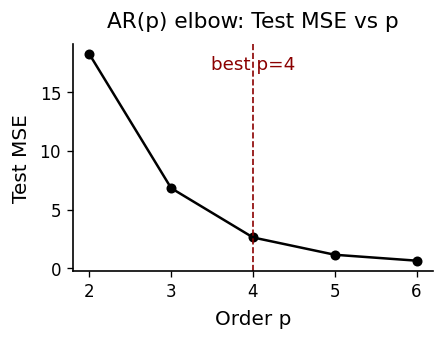

In [6]:
# Sweep AR orders for elbow plot
p_list = list(range(2, 7))
mse_te_list = []
for p in p_list:
    X, y_temp = AR.lag_matrix(xs, p)
    ntr_temp = int(0.9 * len(y_temp))
    X_tr, y_tr = X[:ntr_temp], y_temp[:ntr_temp]
    X_te, y_te = X[ntr_temp:], y_temp[ntr_temp:]
    w_temp = AR.fit(X_tr, y_tr)
    yhat_te = AR.predict_from_params(X_te, w_temp)
    mse_te, _, _ = AR.metrics(y_te, yhat_te)
    mse_te_list.append(mse_te)

best_p_by_mse = p_list[int(np.argmin(mse_te_list))]

def plot_mse_elbow(p_list, mse_list, best_p, color_main="black", color_alt="darkred"):
    fig, ax = plt.subplots(figsize=(4, 3))
    ax.plot(p_list, mse_list, marker='o', color=color_main, lw=1.5, ms=5)
    ax.axvline(best_p, linestyle='--', color=color_alt, linewidth=1)
    ax.text(best_p, ax.get_ylim()[1]*0.95, f"best p={best_p}", ha='center', va='top', color=color_alt, fontsize=11)
    sf = ScalarFormatter(useMathText=True)
    sf.set_powerlimits((-3, 3))
    ax.yaxis.set_major_formatter(sf)
    ax.ticklabel_format(axis='y', style='sci', scilimits=(-3, 3))
    ax.yaxis.get_offset_text().set_size(10)
    prettify(ax, title="AR(p) elbow: Test MSE vs p", xlabel="Order p", ylabel="Test MSE")
    plt.tight_layout()
    plt.show()

plot_mse_elbow(p_list, mse_te_list, 4)

In [7]:
ar_results = fit_ar_model(xs, Fs, p=4, train_frac=0.9, refresh_every=5)

w = ar_results['w']
p_use = ar_results['p']
ntr = ar_results['ntr']
y = ar_results['y']
true_test = ar_results['true_test']
yhat_ctrl = ar_results['yhat_ctrl']
xs_pred_full = ar_results['xs_pred_full']
REFRESH_EVERY = ar_results['refresh_every']

print(f"AR({p_use}): MSE={ar_results['mse']:.6f}, corr={ar_results['corr']:.3f}")

AR(4): MSE=252.627923, corr=0.949


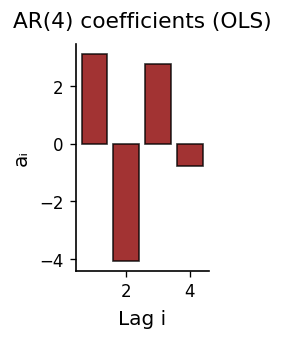

In [8]:
def plot_ar_coefficients(w, p, color_main="black", color_alt="darkred"):
    fig, ax = plt.subplots(figsize=(2, 3))
    ax.bar(np.arange(1, p+1), w[1:], color=color_alt, edgecolor=color_main, alpha=0.8)
    prettify(ax, title=f"AR({p}) coefficients (OLS)", xlabel="Lag i", ylabel="aᵢ")
    plt.tight_layout()
    plt.show()

plot_ar_coefficients(w, p_use)

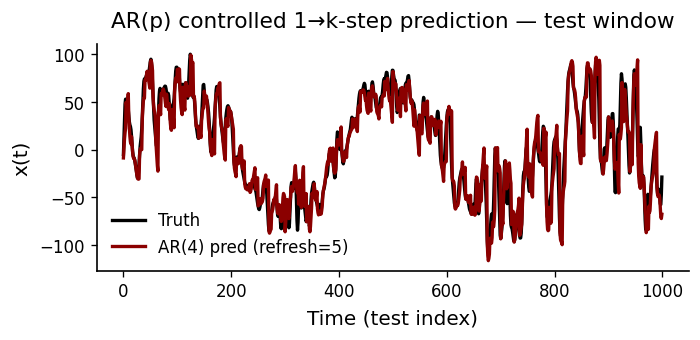

In [9]:
def plot_prediction(y_true, y_pred, p, refresh, color_main="black", color_alt="darkred"):
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.plot(y_true + 1, color=color_main, lw=2, label="Truth")
    ax.plot(y_pred, color=color_alt, lw=2, label=f"AR({p}) pred (refresh={refresh})")
    prettify(ax, title="AR(p) controlled 1→k-step prediction — test window",
             xlabel="Time (test index)", ylabel="x(t)", add_legend=True)
    plt.tight_layout()
    plt.show()

plot_prediction(y[ntr:], yhat_ctrl, p_use, REFRESH_EVERY)

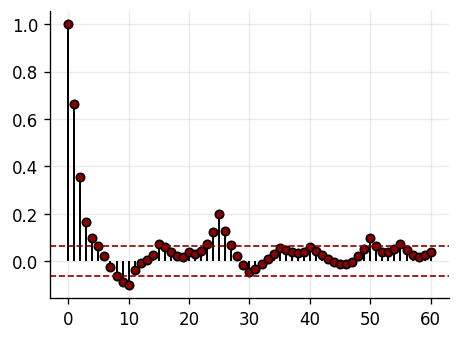

In [10]:
def plot_residual_acf(resid, nlags=60, color_main="black", color_alt="darkred"):
    acf_vals = acf(resid, nlags=nlags)
    bound = 1.96 / np.sqrt(max(len(resid), 1))
    fig, ax = plt.subplots(figsize=(4, 3))
    markerline, stemlines, baseline = ax.stem(range(len(acf_vals)), acf_vals, basefmt=" ")
    plt.setp(stemlines, color=color_main, linewidth=1.2)
    plt.setp(markerline, marker='o', markersize=5, markeredgecolor=color_main, markerfacecolor=color_alt)
    ax.axhline(bound, linestyle='--', color=color_alt, linewidth=1)
    ax.axhline(-bound, linestyle='--', color=color_alt, linewidth=1)
    plt.tight_layout()
    plt.show()

resid_te = y[ntr:] - yhat_ctrl
plot_residual_acf(resid_te)

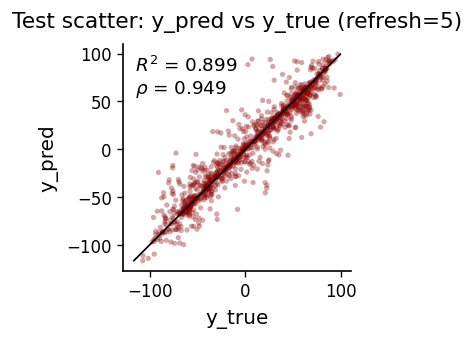

In [11]:
def plot_scatter(y_true, y_pred, refresh, color_main="black", color_alt="darkred"):
    fig, ax = plt.subplots(figsize=(3, 3))
    ax.scatter(y_true, y_pred, c=color_alt, alpha=0.35, s=10, edgecolors="none")
    vmin, vmax = min(np.min(y_true), np.min(y_pred)), max(np.max(y_true), np.max(y_pred))
    ax.plot([vmin, vmax], [vmin, vmax], color=color_main, lw=1)
    yt = y_true - np.mean(y_true)
    yp = y_pred - np.mean(y_pred)
    corr = float((yt @ yp) / np.sqrt((yt @ yt) * (yp @ yp) + 1e-12))
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    r2 = 1 - ss_res / (ss_tot + 1e-12)
    ax.text(0.05, 0.95, f"$R^2$ = {r2:.3f}\n$\\rho$ = {corr:.3f}",
            transform=ax.transAxes, ha='left', va='top', fontsize=11,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, boxstyle="round"))
    ax.set_aspect('equal', adjustable='box')
    prettify(ax, title=f"Test scatter: y_pred vs y_true (refresh={refresh})", xlabel="y_true", ylabel="y_pred")
    plt.tight_layout()
    plt.show()

plot_scatter(y[ntr:], yhat_ctrl, REFRESH_EVERY)

/tmp/ipykernel_13524/3630400991.py:32: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(pad=2.5)


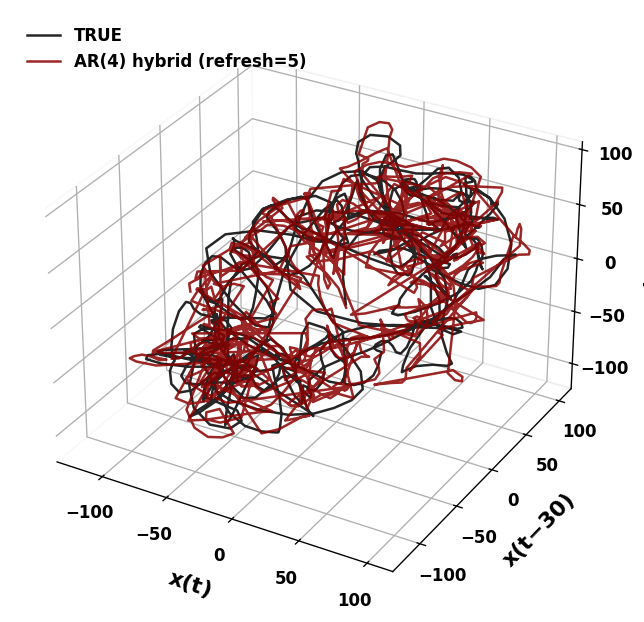

In [12]:
def plot_state_space(X3_true, X3_pred, p, tau, refresh, color_true="black", color_pred="darkred", pred_label=None):
    from matplotlib.ticker import MultipleLocator
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    if pred_label is None:
        pred_label = f"AR({p}) hybrid (refresh={refresh})"
    ax.plot(X3_true[:,0], X3_true[:,1], X3_true[:,2], label="TRUE", color=color_true, alpha=0.85, lw=1.5)
    ax.plot(X3_pred[:,0], X3_pred[:,1], X3_pred[:,2], label=pred_label, color=color_pred, alpha=0.85, lw=1.5)

    # Bold axis labels (LaTeX)
    ax.set_xlabel(r"$\mathbf{x(t)}$", labelpad=8, fontsize=13)
    ax.set_ylabel(f"$\\mathbf{{x(t\\!-\\!{tau})}}$", labelpad=8, fontsize=13)
    ax.set_zlabel(f"$\\mathbf{{x(t\\!-\\!{2*tau})}}$", labelpad=8, fontsize=13)

    # Clean tick spacing: increments of 50
    ax.xaxis.set_major_locator(MultipleLocator(50))
    ax.yaxis.set_major_locator(MultipleLocator(50))
    ax.zaxis.set_major_locator(MultipleLocator(50))
    ax.tick_params(axis='both', pad=4, labelsize=10)

    # Bold tick labels
    for label in ax.xaxis.get_ticklabels() + ax.yaxis.get_ticklabels() + ax.zaxis.get_ticklabels():
        label.set_fontweight('bold')

    # Remove grey background panes
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False

    ax.legend(frameon=False, loc='upper left', fontsize=11, prop={'weight': 'bold'})
    fig.subplots_adjust(left=0.02, right=0.98, bottom=0.12, top=0.95)
    plt.tight_layout(pad=2.5)
    plt.show()

tau = 30
hy = yhat_ctrl - np.mean(yhat_ctrl)
hy = hy * (np.std(true_test) / (np.std(hy) + 1e-12)) + np.mean(true_test)

X3_true = embed(true_test, 3, tau)
X3_hyb = embed(hy, 3, tau)

plot_state_space(X3_true, X3_hyb, p_use, tau, REFRESH_EVERY)

/tmp/ipykernel_13524/2909415279.py:53: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(pad=2.5, w_pad=1.5)


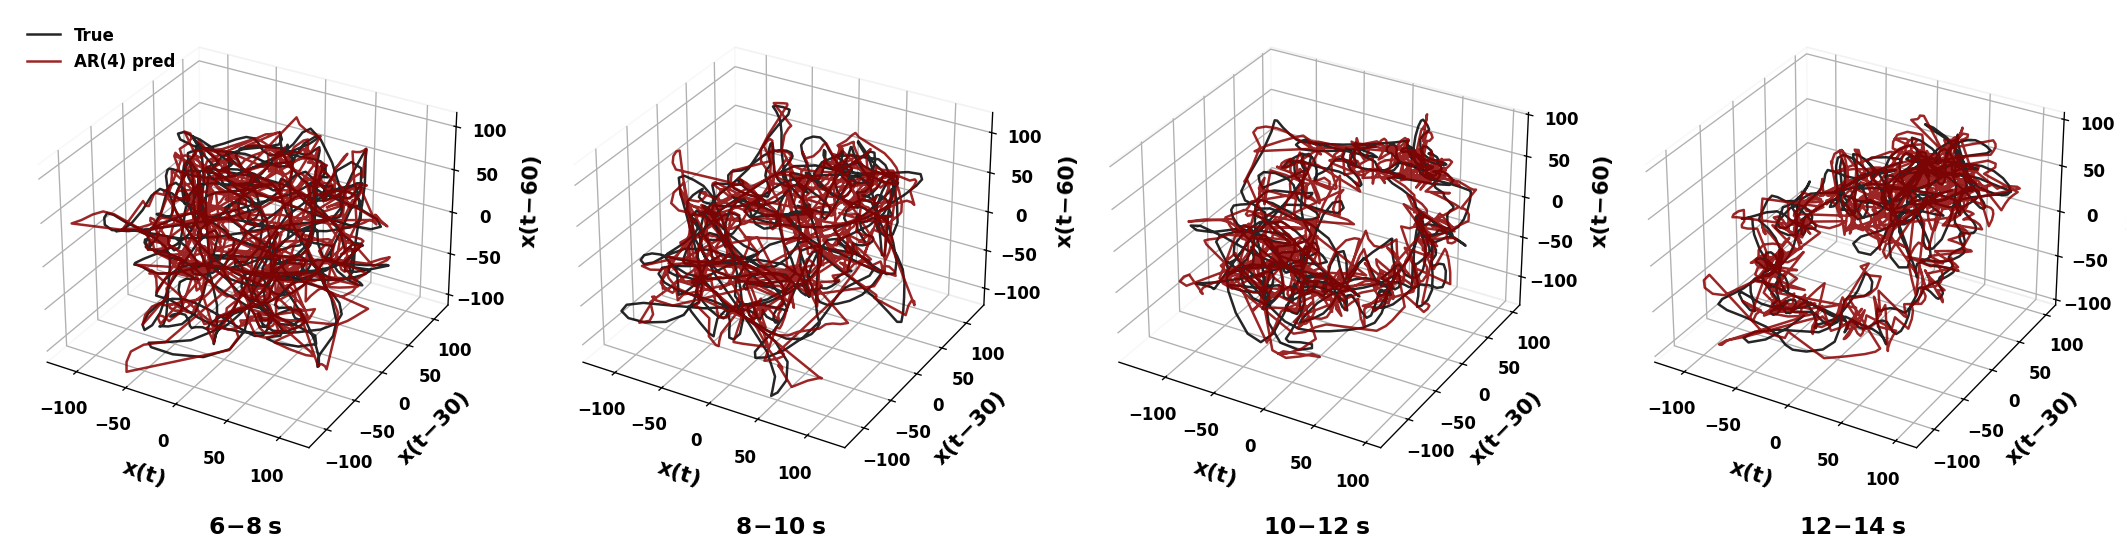

In [13]:

def plot_state_space_windows_comparison(xs, xs_pred, Fs, tau, embed_dim=3,
                                         windows=[(6, 8), (8, 10), (10, 12), (12, 14)], pred_label=None):
    fig, axes = plt.subplots(1, 4, figsize=(len(windows)*4.5, 5), subplot_kw={'projection': '3d'})
    if pred_label is None:
        pred_label = f'AR({p_use}) pred'

    for ax, (t_start, t_end) in zip(axes, windows):
        idx_start = int(t_start * Fs)
        idx_end = int(t_end * Fs)

        # True signal
        segment_true = xs[idx_start:idx_end]
        X3_true = embed(segment_true, embed_dim, tau)

        # Predicted signal (variance-matched)
        segment_pred = xs_pred[idx_start:idx_end]
        seg_pred_matched = segment_pred - np.mean(segment_pred)
        seg_pred_matched = seg_pred_matched * (np.std(segment_true) / (np.std(seg_pred_matched) + 1e-12))
        seg_pred_matched = seg_pred_matched + np.mean(segment_true)
        X3_pred = embed(seg_pred_matched, embed_dim, tau)

        ax.plot(X3_true[:, 0], X3_true[:, 1], X3_true[:, 2], color='black', alpha=0.85, lw=1.5, label='True')
        ax.plot(X3_pred[:, 0], X3_pred[:, 1], X3_pred[:, 2], color='darkred', alpha=0.85, lw=1.5, label=pred_label)

        # Bold axis labels (LaTeX)
        ax.set_xlabel(r"$\mathbf{x(t)}$", labelpad=8, fontsize=13)
        ax.set_ylabel(f"$\\mathbf{{x(t\\!-\\!{tau})}}$", labelpad=8, fontsize=13)
        ax.set_zlabel(f"$\\mathbf{{x(t\\!-\\!{2*tau})}}$", labelpad=8, fontsize=13)

        # Clean tick spacing: increments of 50
        from matplotlib.ticker import MultipleLocator
        ax.xaxis.set_major_locator(MultipleLocator(50))
        ax.yaxis.set_major_locator(MultipleLocator(50))
        ax.zaxis.set_major_locator(MultipleLocator(50))
        ax.tick_params(axis='both', pad=4, labelsize=10)

        # Bold tick labels
        for label in ax.xaxis.get_ticklabels() + ax.yaxis.get_ticklabels() + ax.zaxis.get_ticklabels():
            label.set_fontweight('bold')

        # Remove grey background panes
        ax.xaxis.pane.fill = False
        ax.yaxis.pane.fill = False
        ax.zaxis.pane.fill = False

        # Bold time-window annotation
        ax.text2D(0.5, -0.12, f"$\\mathbf{{{t_start}\\!-\\!{t_end} \\; s}}$",
                  transform=ax.transAxes, ha='center', fontsize=14, fontweight='bold')

    axes[0].legend(frameon=False, loc='upper left', fontsize=11,
                   prop={'weight': 'bold'})
    fig.subplots_adjust(left=0.02, right=0.98, bottom=0.12, top=0.95, wspace=0.15)
    plt.tight_layout(pad=2.5, w_pad=1.5)
    plt.savefig("1.pdf", bbox_inches='tight', dpi=300)
    plt.show()

# Build full prediction for visualization
full_pred = AR.hybrid_predict(xs, w, p_use, start_idx=p_use, n_steps=len(xs)-p_use, refresh_every=REFRESH_EVERY)
xs_pred_full = np.concatenate([xs[:p_use], full_pred])

plot_state_space_windows_comparison(xs, xs_pred_full, Fs, tau)


/tmp/ipykernel_13524/343154526.py:51: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(pad=2.5, w_pad=1.5)


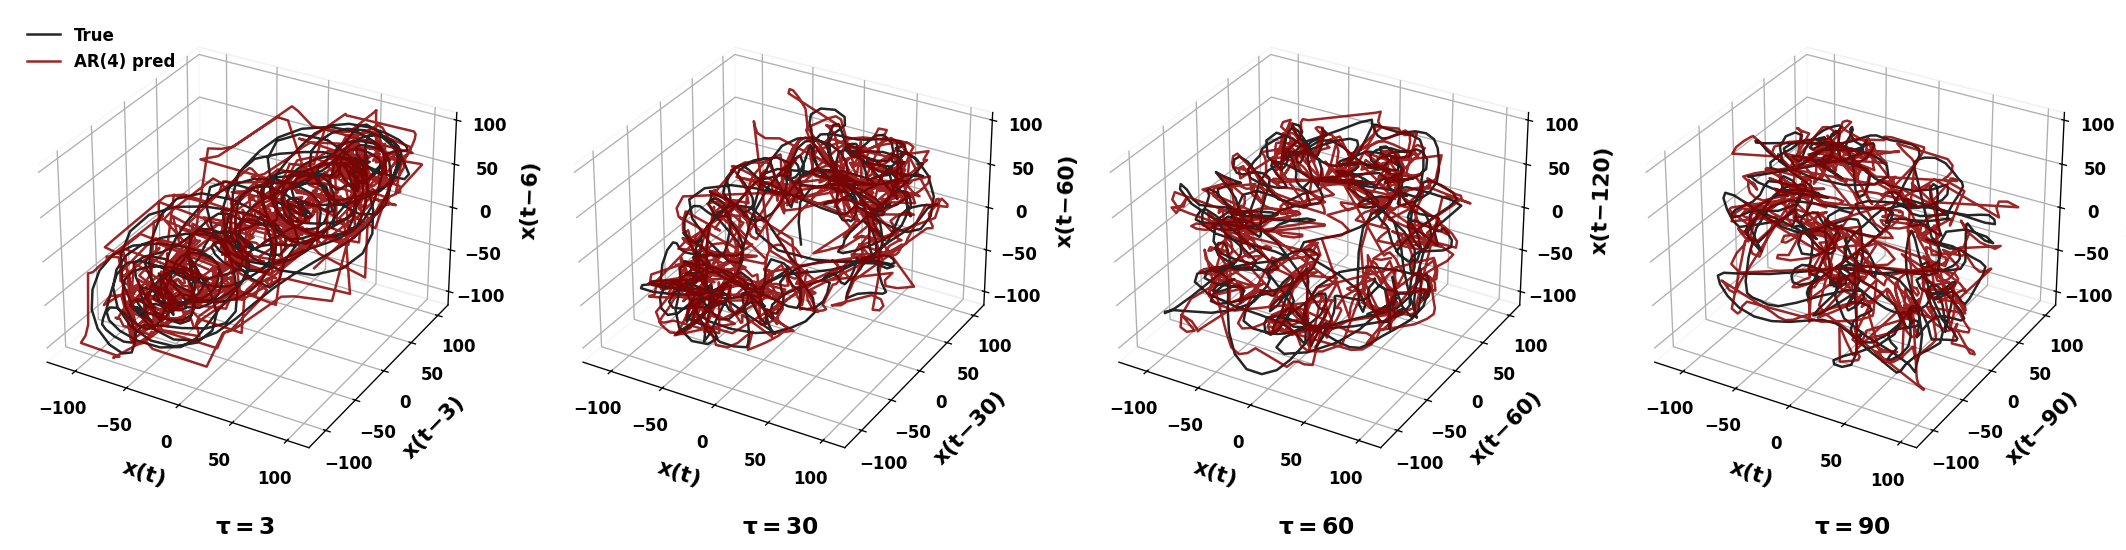

In [14]:

def plot_state_space_tau_sweep(xs, xs_pred, Fs, t_start, t_end, taus=[3, 30, 60, 90], embed_dim=3, pred_label=None):
    from matplotlib.ticker import MultipleLocator
    fig, axes = plt.subplots(1, 4, figsize=(18, 5), subplot_kw={'projection': '3d'})
    if pred_label is None:
        pred_label = f'AR({p_use}) pred'

    idx_start = int(t_start * Fs)
    idx_end = int(t_end * Fs)
    segment_true = xs[idx_start:idx_end]
    segment_pred = xs_pred[idx_start:idx_end]

    # Variance-match prediction
    seg_pred_matched = segment_pred - np.mean(segment_pred)
    seg_pred_matched = seg_pred_matched * (np.std(segment_true) / (np.std(seg_pred_matched) + 1e-12))
    seg_pred_matched = seg_pred_matched + np.mean(segment_true)

    for ax, tau_val in zip(axes, taus):
        X3_true = embed(segment_true, embed_dim, tau_val)
        X3_pred = embed(seg_pred_matched, embed_dim, tau_val)

        ax.plot(X3_true[:, 0], X3_true[:, 1], X3_true[:, 2], color='black', alpha=0.85, lw=1.5, label='True')
        ax.plot(X3_pred[:, 0], X3_pred[:, 1], X3_pred[:, 2], color='darkred', alpha=0.85, lw=1.5, label=pred_label)

        # Bold axis labels (LaTeX)
        ax.set_xlabel(r"$\mathbf{x(t)}$", labelpad=8, fontsize=13)
        ax.set_ylabel(f"$\\mathbf{{x(t\\!-\\!{tau_val})}}$", labelpad=8, fontsize=13)
        ax.set_zlabel(f"$\\mathbf{{x(t\\!-\\!{2*tau_val})}}$", labelpad=8, fontsize=13)

        # Clean tick spacing: increments of 50
        ax.xaxis.set_major_locator(MultipleLocator(50))
        ax.yaxis.set_major_locator(MultipleLocator(50))
        ax.zaxis.set_major_locator(MultipleLocator(50))
        ax.tick_params(axis='both', pad=4, labelsize=10)

        # Bold tick labels
        for label in ax.xaxis.get_ticklabels() + ax.yaxis.get_ticklabels() + ax.zaxis.get_ticklabels():
            label.set_fontweight('bold')

        # Remove grey background panes
        ax.xaxis.pane.fill = False
        ax.yaxis.pane.fill = False
        ax.zaxis.pane.fill = False

        # Bold tau annotation
        ax.text2D(0.5, -0.12, f"$\\mathbf{{\\tau = {tau_val}}}$",
                  transform=ax.transAxes, ha='center', fontsize=14, fontweight='bold')

    axes[0].legend(frameon=False, loc='upper left', fontsize=11,
                   prop={'weight': 'bold'})
    fig.subplots_adjust(left=0.02, right=0.98, bottom=0.12, top=0.95, wspace=0.15)
    plt.tight_layout(pad=2.5, w_pad=1.5)
    plt.savefig("2.pdf", bbox_inches='tight', dpi=300)
    plt.show()

plot_state_space_tau_sweep(xs, xs_pred_full, Fs, t_start=18, t_end=20)


/tmp/ipykernel_13524/874268918.py:78: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(pad=2.5, w_pad=1.5)


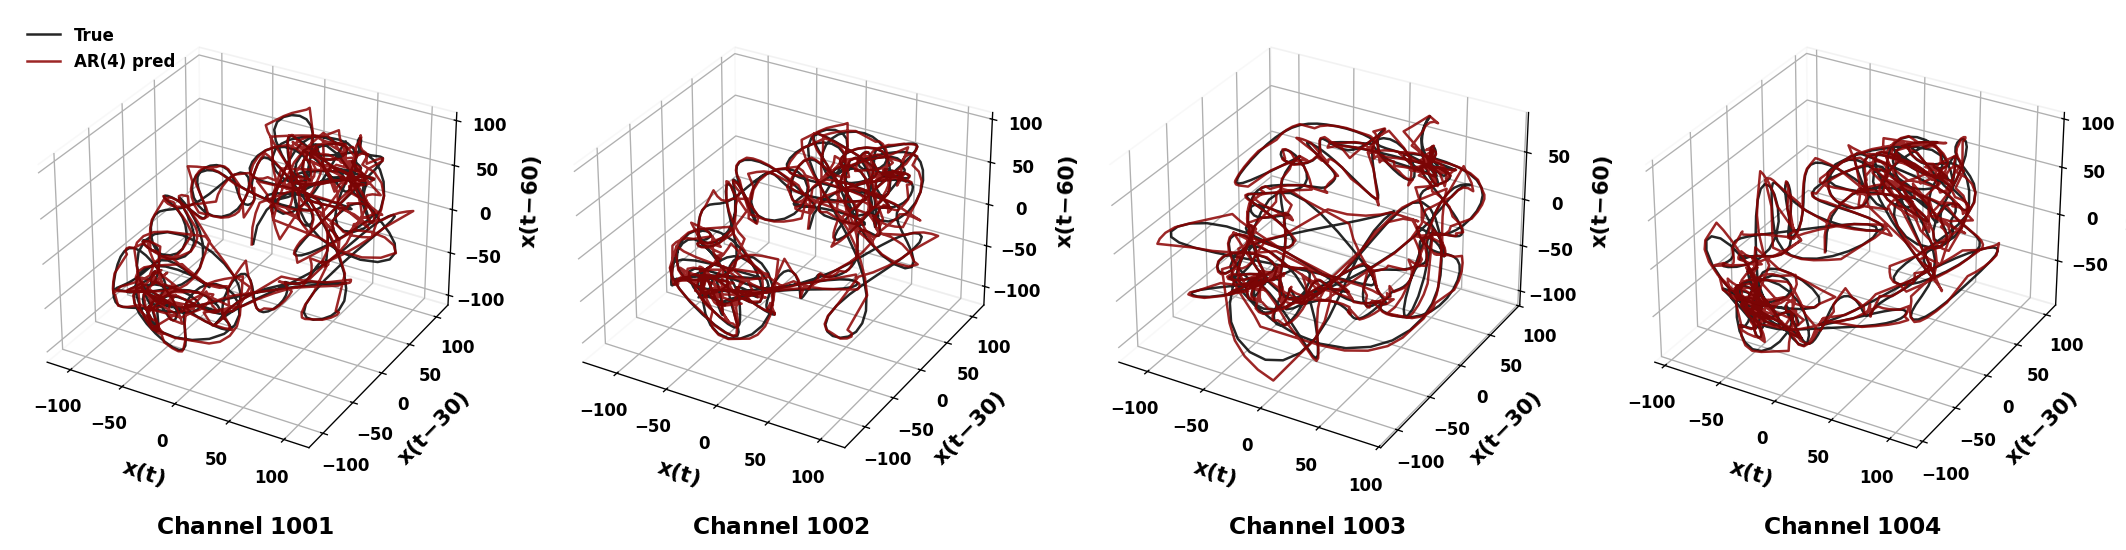

In [15]:
def sweep_channels_plot(LFP, channels, time_windows, taus, Fs, 
                        p=4, train_frac=0.9, refresh_every=5,
                        bandpass_low=1.0, bandpass_high=50.0, fband=(1, 80), env_lp_hz=3.0,
                        embed_dim=3):
    """
    Process multiple channels and plot state space comparison.
    
    Parameters
    ----------
    channels : list of int
        Channel indices to process
    time_windows : list of tuple
        (start_sec, end_sec) for each channel's plot window
    taus : list of int
        Embedding delay for each channel
    """
    from matplotlib.ticker import MultipleLocator
    n = len(channels)
    fig, axes = plt.subplots(1, n, figsize=(n*4.5, 5), subplot_kw={'projection': '3d'})
    if n == 1:
        axes = [axes]
    
    for ax, chan, (t_start, t_end), tau in zip(axes, channels, time_windows, taus):
        # Process full signal for this channel
        xs, _ = process_signal(LFP, chan, Fs, np.arange(int(t_end * Fs) + 100),
                               bandpass_low=bandpass_low, bandpass_high=bandpass_high,
                               fband=fband, env_lp_hz=env_lp_hz)
        
        # Fit AR model
        ar_res = fit_ar_model(xs, Fs, p=p, train_frac=train_frac, refresh_every=refresh_every)
        w, xs_pred_full = ar_res['w'], ar_res['xs_pred_full']
        
        # Extract window
        idx_start, idx_end = int(t_start * Fs), int(t_end * Fs)
        segment_true = xs[idx_start:idx_end]
        segment_pred = xs_pred_full[idx_start:idx_end]
        
        # Variance-match prediction
        seg_pred_matched = segment_pred - np.mean(segment_pred)
        seg_pred_matched = seg_pred_matched * (np.std(segment_true) / (np.std(seg_pred_matched) + 1e-12))
        seg_pred_matched = seg_pred_matched + np.mean(segment_true)
        
        # Embed
        X3_true = embed(segment_true, embed_dim, tau)
        X3_pred = embed(seg_pred_matched, embed_dim, tau)
        
        # Plot
        ax.plot(X3_true[:, 0], X3_true[:, 1], X3_true[:, 2], color='black', alpha=0.85, lw=1.5, label='True')
        ax.plot(X3_pred[:, 0], X3_pred[:, 1], X3_pred[:, 2], color='darkred', alpha=0.85, lw=1.5, label=f'AR({p}) pred')
        
        # Bold axis labels (LaTeX)
        ax.set_xlabel(r"$\mathbf{x(t)}$", labelpad=8, fontsize=13)
        ax.set_ylabel(f"$\\mathbf{{x(t\\!-\\!{tau})}}$", labelpad=8, fontsize=13)
        ax.set_zlabel(f"$\\mathbf{{x(t\\!-\\!{2*tau})}}$", labelpad=8, fontsize=13)
        
        # Clean tick spacing: increments of 50
        ax.xaxis.set_major_locator(MultipleLocator(50))
        ax.yaxis.set_major_locator(MultipleLocator(50))
        ax.zaxis.set_major_locator(MultipleLocator(50))
        ax.tick_params(axis='both', pad=4, labelsize=10)
        
        # Bold tick labels
        for label in ax.xaxis.get_ticklabels() + ax.yaxis.get_ticklabels() + ax.zaxis.get_ticklabels():
            label.set_fontweight('bold')
        
        # Remove grey background panes
        ax.xaxis.pane.fill = False
        ax.yaxis.pane.fill = False
        ax.zaxis.pane.fill = False
        
        # Bold channel annotation
        ax.text2D(0.5, -0.12, f"$\\mathbf{{Channel \\; {chan}}}$",
                  transform=ax.transAxes, ha='center', fontsize=14, fontweight='bold')
    
    axes[0].legend(frameon=False, loc='upper left', fontsize=11,
                   prop={'weight': 'bold'})
    fig.subplots_adjust(left=0.02, right=0.98, bottom=0.12, top=0.95, wspace=0.15)
    plt.tight_layout(pad=2.5, w_pad=1.5)
    plt.savefig("3.pdf", bbox_inches='tight', dpi=300)
    plt.show()
    
sweep_channels_plot(
    LFP, 
    channels=[1001, 1002, 1003, 1004],
    time_windows=[(18, 20), (18, 20), (10, 12), (18, 20)],
    taus=[30, 30, 30, 30],
    Fs=Fs
)


# PINN replacement for OLS AR reconstruction

This section trains a gated TVAR PINN on the same processed monkey LFP signal (`xs`) and uses it for the same controlled rollout that the OLS AR model used above.


In [16]:
# =============================================================================
# PINN replacement for OLS AR reconstruction
# =============================================================================

import torch
import torch.nn as nn


class TVARGatedPINN(nn.Module):
    """Map normalized time -> time-varying AR coefficients with soft lag gates."""

    def __init__(self, p_max, hidden_dim=64, coeff_scale=0.5):
        super().__init__()
        self.p_max = int(p_max)
        self.coeff_scale = float(coeff_scale)
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, self.p_max),
        )
        self.gate_logits = nn.Parameter(torch.full((self.p_max,), 3.0))

    def forward(self, t_norm):
        coeffs = self.coeff_scale * self.net(t_norm)
        gates = torch.sigmoid(self.gate_logits)
        return coeffs * gates, gates


def torch_lag_matrix(x, p):
    """Columns are [x[t-1], x[t-2], ..., x[t-p]], target is x[t]."""
    cols = [x[p - k:-k] for k in range(1, p + 1)]
    return torch.stack(cols, dim=1), x[p:]


def sliding_power_loss(x_hat, target_power, W):
    if x_hat.numel() <= W:
        return x_hat.new_tensor(0.0)
    powers = x_hat.unfold(0, W, 1).pow(2).mean(dim=1)
    return torch.mean((powers - target_power) ** 2)


def pinn_hybrid_predict(series_norm, coeffs_by_time, p, start_idx, n_steps, refresh_every=5):
    """Controlled 1->k-step rollout using learned time-varying coefficients."""
    preds = []
    hist = series_norm[start_idx - p:start_idx].astype(float).tolist()

    for step in range(n_steps):
        abs_idx = start_idx + step
        if (step % max(int(refresh_every), 1)) == 0:
            hist = series_norm[abs_idx - p:abs_idx].astype(float).tolist()

        coeff = coeffs_by_time[abs_idx - p]
        pred = float(np.dot(coeff, list(reversed(hist))))
        preds.append(pred)
        hist.pop(0)
        hist.append(pred)

    return np.asarray(preds, dtype=float)


def fit_pinn_ar_model(
    xs,
    p=4,
    train_frac=0.9,
    refresh_every=5,
    n_epochs=1000,
    lr=1e-3,
    hidden_dim=64,
    coeff_scale=0.5,
    W=40,
    lambda_energy=1e-3,
    lambda_smooth=1e-2,
    lambda_gate=1e-4,
    seed=7,
):
    torch.manual_seed(seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    xs = np.asarray(xs, dtype=np.float32)
    mu = float(xs.mean())
    sigma = float(xs.std() + 1e-12)
    xs_norm = (xs - mu) / sigma

    x_torch = torch.tensor(xs_norm, dtype=torch.float32, device=device)
    X_lag, y_all = torch_lag_matrix(x_torch, p)

    ntr_local = int(train_frac * len(y_all))
    start_idx = p + ntr_local
    n_test = len(y_all) - ntr_local

    t_norm = torch.linspace(0.0, 1.0, len(y_all), device=device).view(-1, 1)
    target_power = y_all[:ntr_local].pow(2).mean().detach()

    pinn = TVARGatedPINN(p_max=p, hidden_dim=hidden_dim, coeff_scale=coeff_scale).to(device)
    optimizer = torch.optim.Adam(pinn.parameters(), lr=lr)
    history = {"loss": [], "ar": [], "energy": [], "smooth": [], "gate": []}

    for epoch in range(n_epochs):
        pinn.train()
        optimizer.zero_grad()

        coeffs, gates = pinn(t_norm)
        x_hat_all = torch.sum(coeffs * X_lag, dim=1)
        x_hat_train = x_hat_all[:ntr_local]
        y_train = y_all[:ntr_local]
        coeffs_train = coeffs[:ntr_local]

        loss_ar = torch.mean((x_hat_train - y_train) ** 2)
        loss_energy = sliding_power_loss(x_hat_train, target_power, W)
        loss_smooth = torch.mean((coeffs_train[1:] - coeffs_train[:-1]).pow(2))
        loss_gate = torch.mean(torch.abs(gates))
        loss = loss_ar + lambda_energy * loss_energy + lambda_smooth * loss_smooth + lambda_gate * loss_gate

        loss.backward()
        torch.nn.utils.clip_grad_norm_(pinn.parameters(), max_norm=1.0)
        optimizer.step()

        if epoch == 0 or (epoch + 1) % 100 == 0 or epoch == n_epochs - 1:
            history["loss"].append(float(loss.detach().cpu()))
            history["ar"].append(float(loss_ar.detach().cpu()))
            history["energy"].append(float(loss_energy.detach().cpu()))
            history["smooth"].append(float(loss_smooth.detach().cpu()))
            history["gate"].append(float(loss_gate.detach().cpu()))
            print(
                f"epoch {epoch + 1:4d}/{n_epochs} | "
                f"loss={history['loss'][-1]:.5f} | ar={history['ar'][-1]:.5f} | "
                f"energy={history['energy'][-1]:.5f} | smooth={history['smooth'][-1]:.5f}"
            )

    pinn.eval()
    with torch.no_grad():
        coeffs_all, gates = pinn(t_norm)
        teacher_forced = torch.sum(coeffs_all * X_lag, dim=1)

    coeffs_all = coeffs_all.cpu().numpy()
    gates = gates.cpu().numpy()
    teacher_forced = teacher_forced.cpu().numpy()

    y_pred_norm = pinn_hybrid_predict(
        xs_norm,
        coeffs_all,
        p=p,
        start_idx=start_idx,
        n_steps=n_test,
        refresh_every=refresh_every,
    )
    y_pred = y_pred_norm * sigma + mu
    y_true = xs[start_idx:start_idx + n_test]

    full_pred_norm = pinn_hybrid_predict(
        xs_norm,
        coeffs_all,
        p=p,
        start_idx=p,
        n_steps=len(xs) - p,
        refresh_every=refresh_every,
    )
    xs_pred_full = np.concatenate([xs[:p], full_pred_norm * sigma + mu])

    mse, mae, corr = AR.metrics(y_true, y_pred)
    return {
        "model": pinn,
        "history": history,
        "coeffs": coeffs_all,
        "gates": gates,
        "p": p,
        "ntr": ntr_local,
        "start_idx": start_idx,
        "n_test": n_test,
        "y_true": y_true,
        "y_pred": y_pred,
        "xs_pred_full": xs_pred_full,
        "teacher_forced_full": np.concatenate([xs[:p], teacher_forced * sigma + mu]),
        "mse": mse,
        "mae": mae,
        "corr": corr,
    }


In [17]:
# Train the PINN on the same signal/order used by the OLS AR model.
# If this is slow on CPU, reduce n_epochs to 300 first.
pinn_results = fit_pinn_ar_model(
    xs,
    p=p_use,
    train_frac=0.9,
    refresh_every=REFRESH_EVERY,
    n_epochs=1000,
    lr=1e-3,
    hidden_dim=64,
    coeff_scale=0.5,
    W=40,
    lambda_energy=1e-3,
    lambda_smooth=1e-2,
    lambda_gate=1e-4,
    seed=7,
)

y_pred_pinn = pinn_results["y_pred"]
y_true_pinn = pinn_results["y_true"]
xs_pred_pinn_full = pinn_results["xs_pred_full"]

print(f"PINN-TVAR({p_use}): MSE={pinn_results['mse']:.6f}, MAE={pinn_results['mae']:.6f}, corr={pinn_results['corr']:.4f}")
print(f"Learned gates: {np.round(pinn_results['gates'], 3)}")


epoch    1/1000 | loss=0.78726 | ar=0.78623 | energy=0.94306 | smooth=0.00000
epoch  100/1000 | loss=0.01652 | ar=0.01618 | energy=0.24193 | smooth=0.00000
epoch  200/1000 | loss=0.00872 | ar=0.00838 | energy=0.24690 | smooth=0.00000
epoch  300/1000 | loss=0.00659 | ar=0.00624 | energy=0.25143 | smooth=0.00000
epoch  400/1000 | loss=0.00604 | ar=0.00569 | energy=0.25311 | smooth=0.00000
epoch  500/1000 | loss=0.00561 | ar=0.00526 | energy=0.25359 | smooth=0.00000
epoch  600/1000 | loss=0.00517 | ar=0.00482 | energy=0.25383 | smooth=0.00000
epoch  700/1000 | loss=0.00472 | ar=0.00437 | energy=0.25407 | smooth=0.00000
epoch  800/1000 | loss=0.00427 | ar=0.00392 | energy=0.25433 | smooth=0.00000
epoch  900/1000 | loss=0.00382 | ar=0.00347 | energy=0.25462 | smooth=0.00000
epoch 1000/1000 | loss=0.00340 | ar=0.00305 | energy=0.25493 | smooth=0.00000
PINN-TVAR(4): MSE=303.682445, MAE=11.350322, corr=0.9375
Learned gates: [0.957 0.956 0.953 0.952]


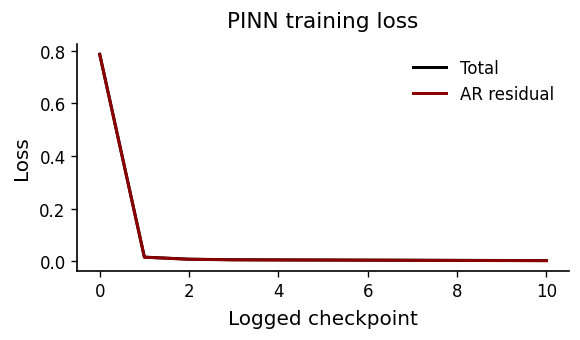

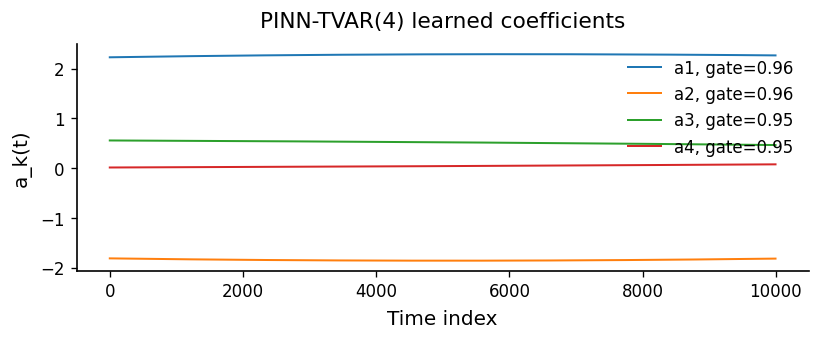

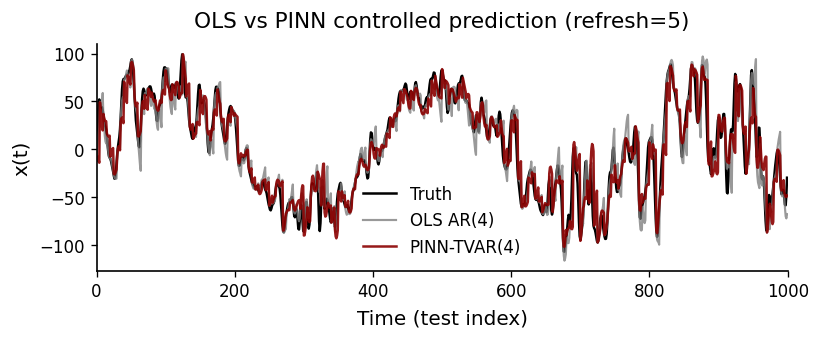

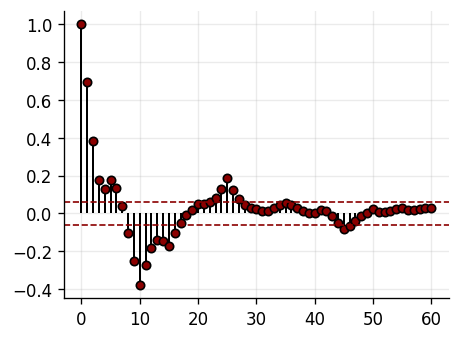

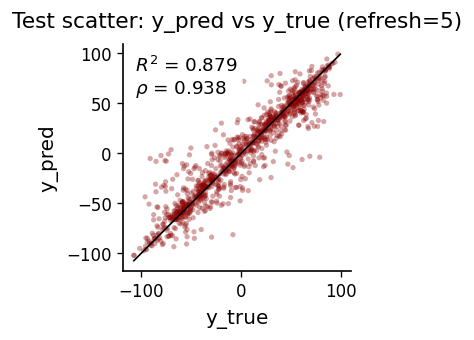

/tmp/ipykernel_13524/3630400991.py:32: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(pad=2.5)


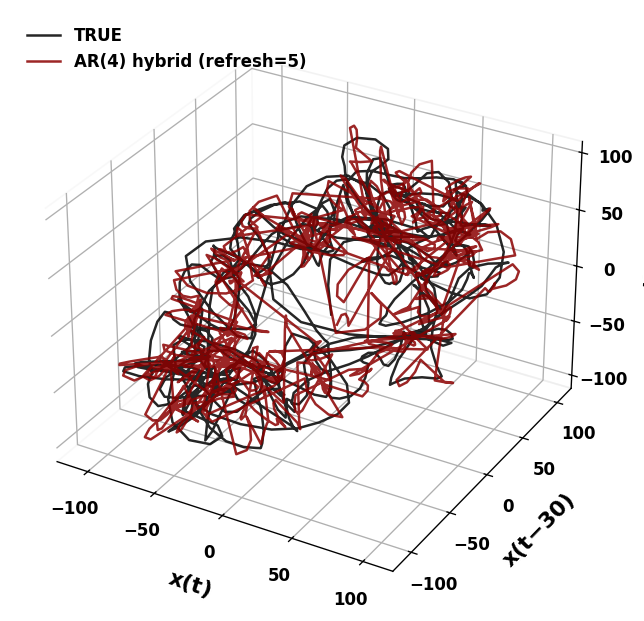

/tmp/ipykernel_13524/2909415279.py:53: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(pad=2.5, w_pad=1.5)


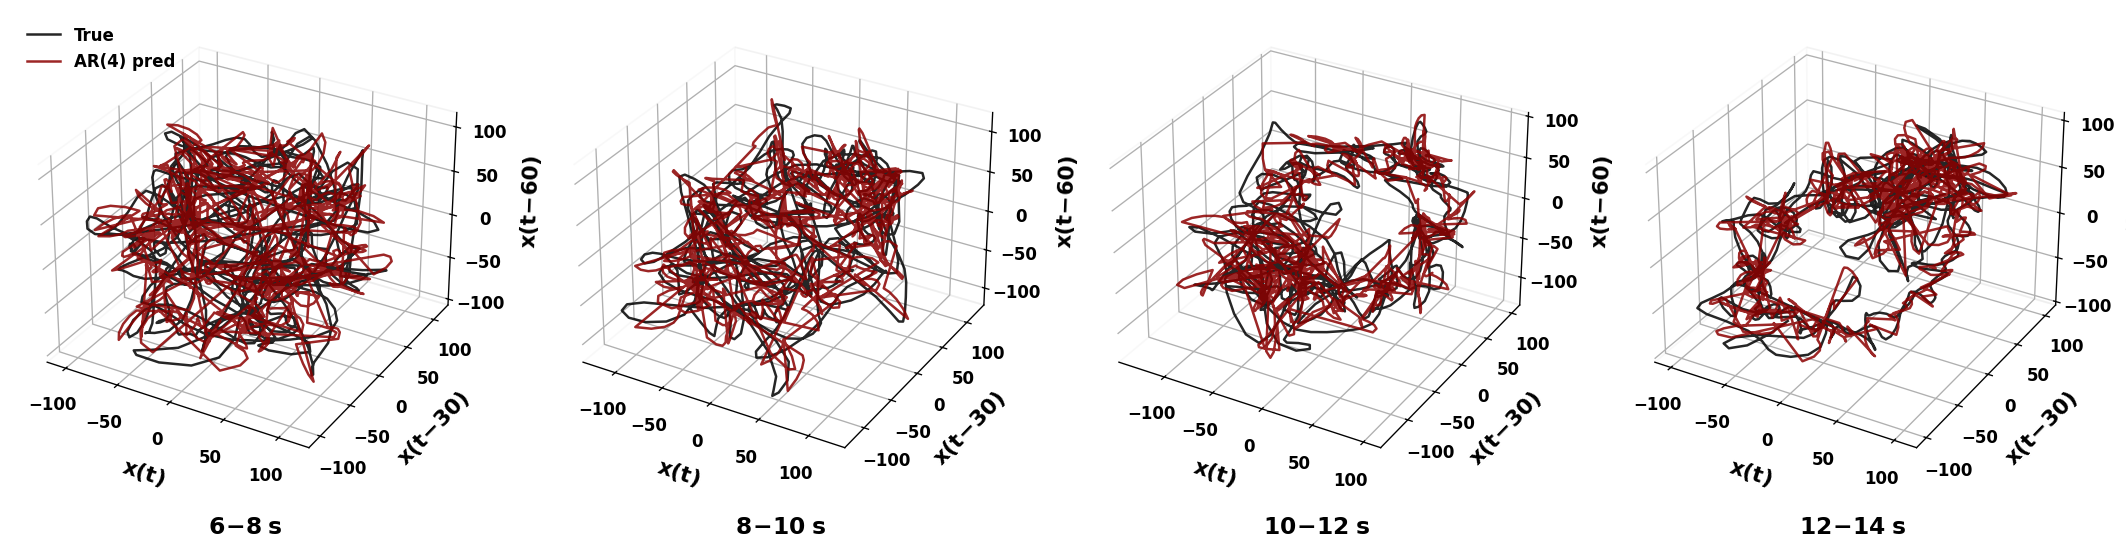

/tmp/ipykernel_13524/343154526.py:51: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(pad=2.5, w_pad=1.5)


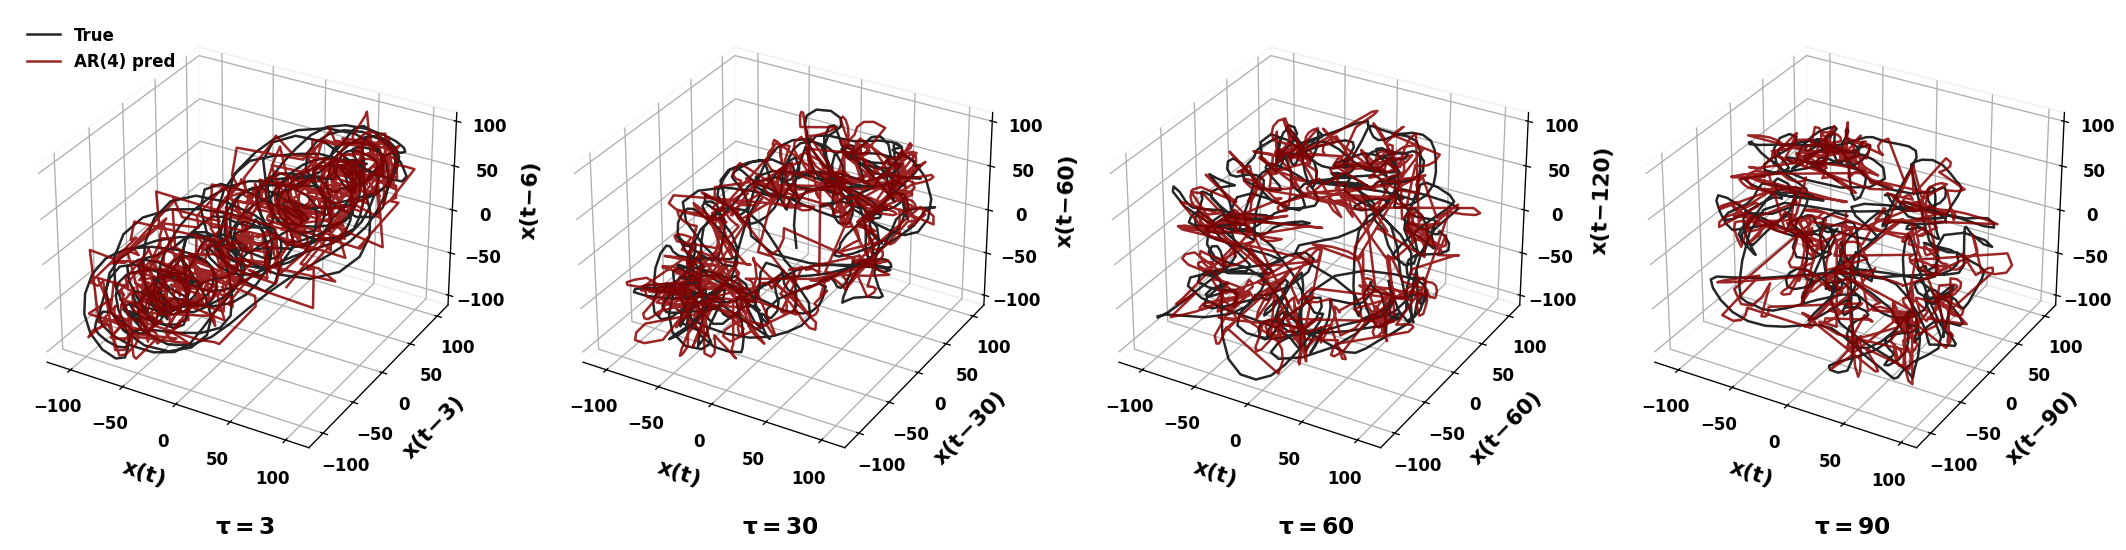

In [18]:
# =============================================================================
# PINN diagnostics and OLS comparison
# =============================================================================

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(pinn_results["history"]["loss"], color="black", label="Total")
ax.plot(pinn_results["history"]["ar"], color="darkred", label="AR residual")
prettify(ax, title="PINN training loss", xlabel="Logged checkpoint", ylabel="Loss", add_legend=True)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 3))
for k in range(p_use):
    ax.plot(pinn_results["coeffs"][:, k], lw=1.2, label=f"a{k+1}, gate={pinn_results['gates'][k]:.2f}")
prettify(ax, title=f"PINN-TVAR({p_use}) learned coefficients", xlabel="Time index", ylabel="a_k(t)", add_legend=True)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(y[ntr:], color="black", lw=1.5, label="Truth")
ax.plot(yhat_ctrl, color="gray", lw=1.3, alpha=0.8, label=f"OLS AR({p_use})")
ax.plot(y_pred_pinn, color="darkred", lw=1.5, alpha=0.9, label=f"PINN-TVAR({p_use})")
prettify(ax, title=f"OLS vs PINN controlled prediction (refresh={REFRESH_EVERY})", xlabel="Time (test index)", ylabel="x(t)", add_legend=True)
ax.set_xlim(0, min(1000, len(y[ntr:])))
plt.tight_layout()
plt.show()

pinn_resid = y_true_pinn - y_pred_pinn
plot_residual_acf(pinn_resid)
plot_scatter(y_true_pinn, y_pred_pinn, REFRESH_EVERY)

# State-space comparison using the same delay embedding setup as above.
y_pred_pinn_matched = y_pred_pinn - y_pred_pinn.mean()
y_pred_pinn_matched = y_pred_pinn_matched * (y_true_pinn.std() / (y_pred_pinn_matched.std() + 1e-12)) + y_true_pinn.mean()
X3_true_pinn = embed(y_true_pinn, m=3, tau=tau)
X3_pinn = embed(y_pred_pinn_matched, m=3, tau=tau)
plot_state_space(X3_true_pinn, X3_pinn, p_use, tau, REFRESH_EVERY)

plot_state_space_windows_comparison(xs, xs_pred_pinn_full, Fs, tau)
plot_state_space_tau_sweep(xs, xs_pred_pinn_full, Fs, t_start=18, t_end=20)


In [19]:
import torch
from torch.utils.data import DataLoader, TensorDataset
from NeuralFieldManifold.models import DeepLagEmbed as DeepLagField
from NeuralFieldManifold.utils.losses import loss_ar, loss_energy, loss_smooth, loss_order


def make_lfp_windows(x, seq_len=600, stride=120):
    x = np.asarray(x, dtype=np.float32)
    starts = np.arange(0, len(x) - seq_len + 1, stride, dtype=int)
    windows = np.stack([x[s:s + seq_len] for s in starts]).astype(np.float32)
    return windows, starts


def normalize_windows(windows):
    mu = windows.mean(axis=1, keepdims=True)
    sigma = windows.std(axis=1, keepdims=True) + 1e-6
    return (windows - mu) / sigma, mu.squeeze(1), sigma.squeeze(1)


def train_deeplagfield_on_lfp(
    xs,
    seq_len=600,
    stride=120,
    max_ar_order=6,
    hidden_dim=128,
    batch_size=32,
    n_epochs=200,
    lr=1e-3,
    lambda_ar=1.0,
    lambda_energy=1e-3,
    lambda_smooth=1e-2,
    lambda_order=1e-3,
    temperature=1.0,
    seed=7,
):
    torch.manual_seed(seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    windows, starts = make_lfp_windows(xs, seq_len=seq_len, stride=stride)
    windows_norm, mu, sigma = normalize_windows(windows)

    X = torch.tensor(windows_norm, dtype=torch.float32)
    loader = DataLoader(TensorDataset(X), batch_size=batch_size, shuffle=True)

    model = DeepLagField(
        seq_len=seq_len,
        n_classes=max_ar_order - 1,
        max_ar_order=max_ar_order,
        hidden_dim=hidden_dim,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"loss": [], "ar": [], "energy": [], "smooth": [], "order": []}

    for epoch in range(n_epochs):
        model.train()
        totals = {k: [] for k in history}

        for (xb,) in loader:
            xb = xb.to(device)
            optimizer.zero_grad()

            coeffs, p_logits, p_hard, x_hat = model(xb, temperature=temperature)

            l_ar = loss_ar(xb, x_hat, max_ar_order)
            l_energy = loss_energy(x_hat, P0=1.0, W=40)
            l_smooth = loss_smooth(coeffs)
            l_order = loss_order(p_logits)

            loss = (
                lambda_ar * l_ar
                + lambda_energy * l_energy
                + lambda_smooth * l_smooth
                + lambda_order * l_order
            )

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            totals["loss"].append(float(loss.detach().cpu()))
            totals["ar"].append(float(l_ar.detach().cpu()))
            totals["energy"].append(float(l_energy.detach().cpu()))
            totals["smooth"].append(float(l_smooth.detach().cpu()))
            totals["order"].append(float(l_order.detach().cpu()))

        for key in history:
            history[key].append(float(np.mean(totals[key])))

        if epoch == 0 or (epoch + 1) % 25 == 0 or epoch == n_epochs - 1:
            print(
                f"epoch {epoch + 1:4d}/{n_epochs} | "
                f"loss={history['loss'][-1]:.5f} | "
                f"ar={history['ar'][-1]:.5f} | "
                f"smooth={history['smooth'][-1]:.5f}"
            )

    return {
        "model": model,
        "history": history,
        "windows": windows,
        "windows_norm": windows_norm,
        "starts": starts,
        "mu": mu,
        "sigma": sigma,
        "seq_len": seq_len,
        "stride": stride,
        "max_ar_order": max_ar_order,
        "device": device,
    }


def deeplagfield_predict_all(result, batch_size=64, temperature=0.25):
    model = result["model"]
    device = result["device"]

    X = torch.tensor(result["windows_norm"], dtype=torch.float32)
    loader = DataLoader(TensorDataset(X), batch_size=batch_size, shuffle=False)

    coeffs_all, p_all, xhat_all = [], [], []

    model.eval()
    with torch.no_grad():
        for (xb,) in loader:
            xb = xb.to(device)
            coeffs, p_logits, p_hard, x_hat = model(xb, temperature=temperature)
            coeffs_all.append(coeffs.cpu().numpy())
            p_all.append(p_hard.cpu().numpy())
            xhat_all.append(x_hat.cpu().numpy())

    coeffs_all = np.concatenate(coeffs_all, axis=0)
    p_all = np.concatenate(p_all, axis=0)
    xhat_norm = np.concatenate(xhat_all, axis=0)
    xhat = xhat_norm * result["sigma"][:, None] + result["mu"][:, None]

    return {
        "coeffs": coeffs_all,
        "p_class": p_all,
        "p_order": p_all + 2,
        "xhat_norm": xhat_norm,
        "xhat": xhat,
    }


def overlap_add_windows(windows, starts, signal_len):
    out = np.zeros(signal_len, dtype=float)
    weight = np.zeros(signal_len, dtype=float)

    for win, start in zip(windows, starts):
        end = min(start + len(win), signal_len)
        n = end - start
        out[start:end] += win[:n]
        weight[start:end] += 1.0

    valid = weight > 0
    out[valid] /= weight[valid]
    out[~valid] = np.nan
    return out, valid

In [20]:
deeplag_result = train_deeplagfield_on_lfp(
    xs,
    seq_len=1600,
    stride=120,
    max_ar_order=5,
    hidden_dim=256,
    batch_size=16,
    n_epochs=300,  # use 25 for a quick smoke test
    lr=1e-3,
    lambda_ar=3.0,
    lambda_energy=1e-3,
    lambda_smooth=1e-2,
    lambda_order=1e-3,
    temperature=1.0,
    seed=7,
)

deeplag_pred = deeplagfield_predict_all(deeplag_result, temperature=0.25)

xs_deeplag_full, deeplag_valid = overlap_add_windows(
    deeplag_pred["xhat"],
    deeplag_result["starts"],
    len(xs),
)

print(f"Windows: {deeplag_result['windows'].shape[0]}")
print(f"Predicted TVAR orders: {dict(zip(*np.unique(deeplag_pred['p_order'], return_counts=True)))}")


epoch    1/300 | loss=2.06568 | ar=0.68749 | smooth=0.13843
epoch   25/300 | loss=0.13835 | ar=0.04556 | smooth=0.10377
epoch   50/300 | loss=0.02987 | ar=0.00970 | smooth=0.04900
epoch   75/300 | loss=0.05191 | ar=0.01700 | smooth=0.04344
epoch  100/300 | loss=0.02316 | ar=0.00751 | smooth=0.03730
epoch  125/300 | loss=0.00717 | ar=0.00216 | smooth=0.03704
epoch  150/300 | loss=0.00401 | ar=0.00111 | smooth=0.03980
epoch  175/300 | loss=0.03553 | ar=0.01161 | smooth=0.03782
epoch  200/300 | loss=0.02197 | ar=0.00714 | smooth=0.03187
epoch  225/300 | loss=0.00345 | ar=0.00093 | smooth=0.03663
epoch  250/300 | loss=0.02110 | ar=0.00683 | smooth=0.03542
epoch  275/300 | loss=0.00885 | ar=0.00275 | smooth=0.03345
epoch  300/300 | loss=0.02780 | ar=0.00900 | smooth=0.03768
Windows: 71
Predicted TVAR orders: {np.int64(2): np.int64(71)}


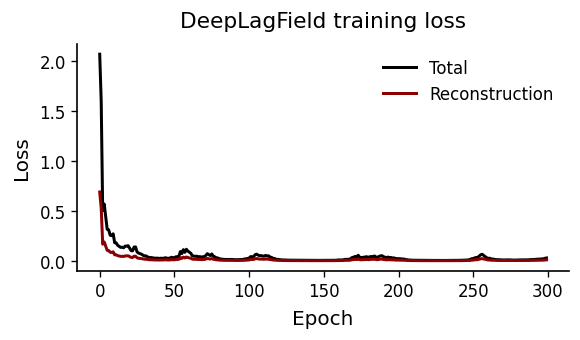

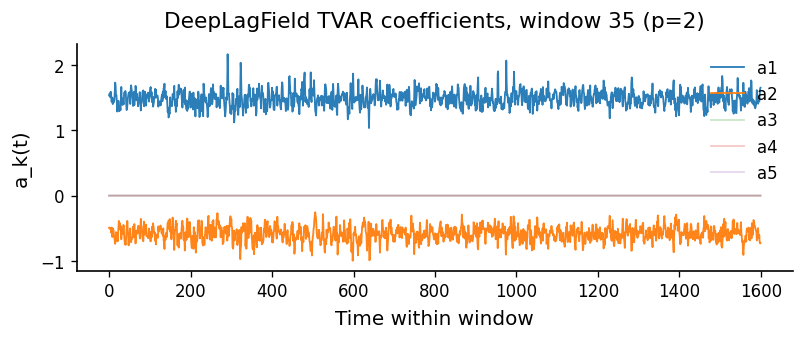

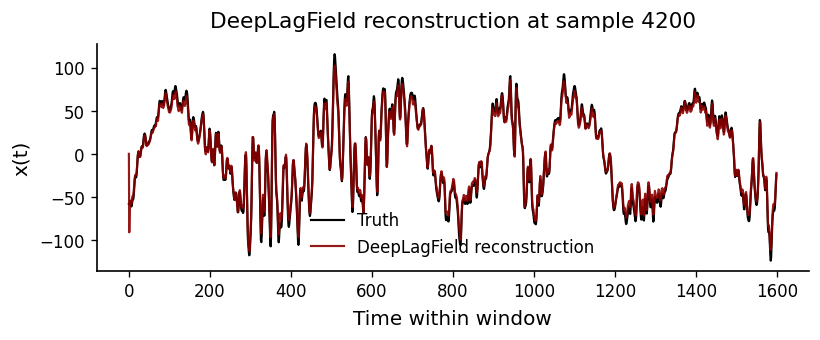

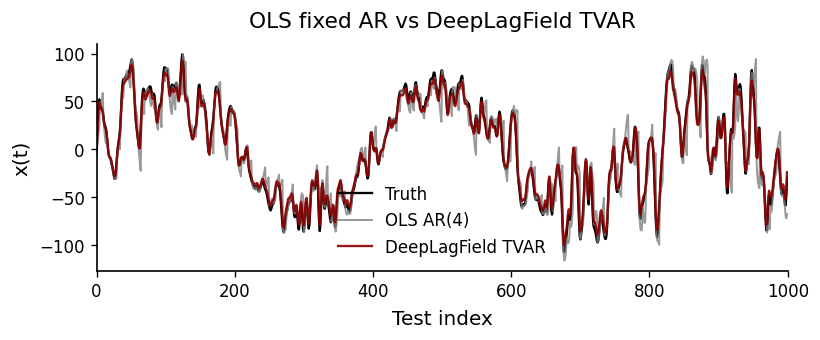

DeepLagField test overlap: MSE=16.475477, corr=0.9997


In [21]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(deeplag_result["history"]["loss"], color="black", label="Total")
ax.plot(deeplag_result["history"]["ar"], color="darkred", label="Reconstruction")
prettify(ax, title="DeepLagField training loss", xlabel="Epoch", ylabel="Loss", add_legend=True)
plt.tight_layout()
plt.show()

test_start = p_use + ntr
test_candidates = np.where(deeplag_result["starts"] >= test_start)[0]
example_idx = int(test_candidates[0]) if len(test_candidates) else len(deeplag_result["starts"]) // 2

example_start = int(deeplag_result["starts"][example_idx])
example_true = deeplag_result["windows"][example_idx]
example_xhat = deeplag_pred["xhat"][example_idx]
example_coeffs = deeplag_pred["coeffs"][example_idx]
example_order = int(deeplag_pred["p_order"][example_idx])

fig, ax = plt.subplots(figsize=(7, 3))
for k in range(deeplag_result["max_ar_order"]):
    alpha = 0.95 if k < example_order else 0.25
    ax.plot(example_coeffs[:, k], lw=1.1, alpha=alpha, label=f"a{k+1}")

prettify(
    ax,
    title=f"DeepLagField TVAR coefficients, window {example_idx} (p={example_order})",
    xlabel="Time within window",
    ylabel="a_k(t)",
    add_legend=True,
)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(example_true, color="black", lw=1.3, label="Truth")
ax.plot(example_xhat, color="darkred", lw=1.3, alpha=0.9, label="DeepLagField reconstruction")
prettify(
    ax,
    title=f"DeepLagField reconstruction at sample {example_start}",
    xlabel="Time within window",
    ylabel="x(t)",
    add_legend=True,
)
plt.tight_layout()
plt.show()

deeplag_test_pred = xs_deeplag_full[p_use + ntr:p_use + ntr + len(yhat_ctrl)]
deeplag_test_true = y[ntr:ntr + len(deeplag_test_pred)]
mask = np.isfinite(deeplag_test_pred)

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(deeplag_test_true, color="black", lw=1.4, label="Truth")
ax.plot(
    yhat_ctrl[:len(deeplag_test_true)],
    color="gray",
    lw=1.2,
    alpha=0.8,
    label=f"OLS AR({p_use})",
)
ax.plot(
    deeplag_test_pred,
    color="darkred",
    lw=1.4,
    alpha=0.9,
    label="DeepLagField TVAR",
)
prettify(
    ax,
    title="OLS fixed AR vs DeepLagField TVAR",
    xlabel="Test index",
    ylabel="x(t)",
    add_legend=True,
)
ax.set_xlim(0, min(1000, len(deeplag_test_true)))
plt.tight_layout()
plt.show()

if mask.any():
    mse_dle = float(np.mean((deeplag_test_true[mask] - deeplag_test_pred[mask]) ** 2))
    corr_dle = float(np.corrcoef(deeplag_test_true[mask], deeplag_test_pred[mask])[0, 1])
    print(f"DeepLagField test overlap: MSE={mse_dle:.6f}, corr={corr_dle:.4f}")


/tmp/ipykernel_13524/3630400991.py:32: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(pad=2.5)


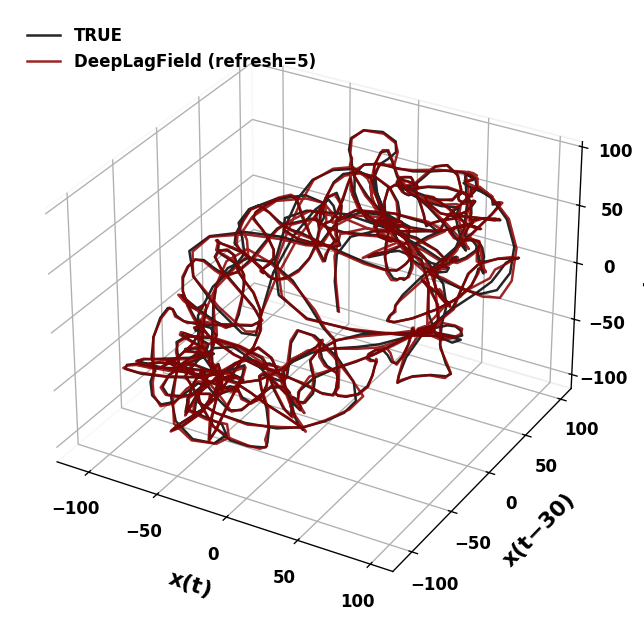

In [22]:
# =============================================================================
# DeepLagField delay-embedding / torus comparison
# =============================================================================

segment_true = deeplag_test_true[mask]
segment_pred = deeplag_test_pred[mask]

# Variance-match DeepLagField reconstruction for fair geometry comparison
segment_pred_matched = segment_pred - np.mean(segment_pred)
segment_pred_matched = (
    segment_pred_matched
    * (np.std(segment_true) / (np.std(segment_pred_matched) + 1e-12))
    + np.mean(segment_true)
)

X3_true_dle = embed(segment_true, m=3, tau=tau)
X3_dle = embed(segment_pred_matched, m=3, tau=tau)

plot_state_space(
    X3_true_dle,
    X3_dle,
    example_order,
    tau,
    REFRESH_EVERY,
    pred_label=f"DeepLagField (refresh={REFRESH_EVERY})",
)


/tmp/ipykernel_13524/2909415279.py:53: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(pad=2.5, w_pad=1.5)


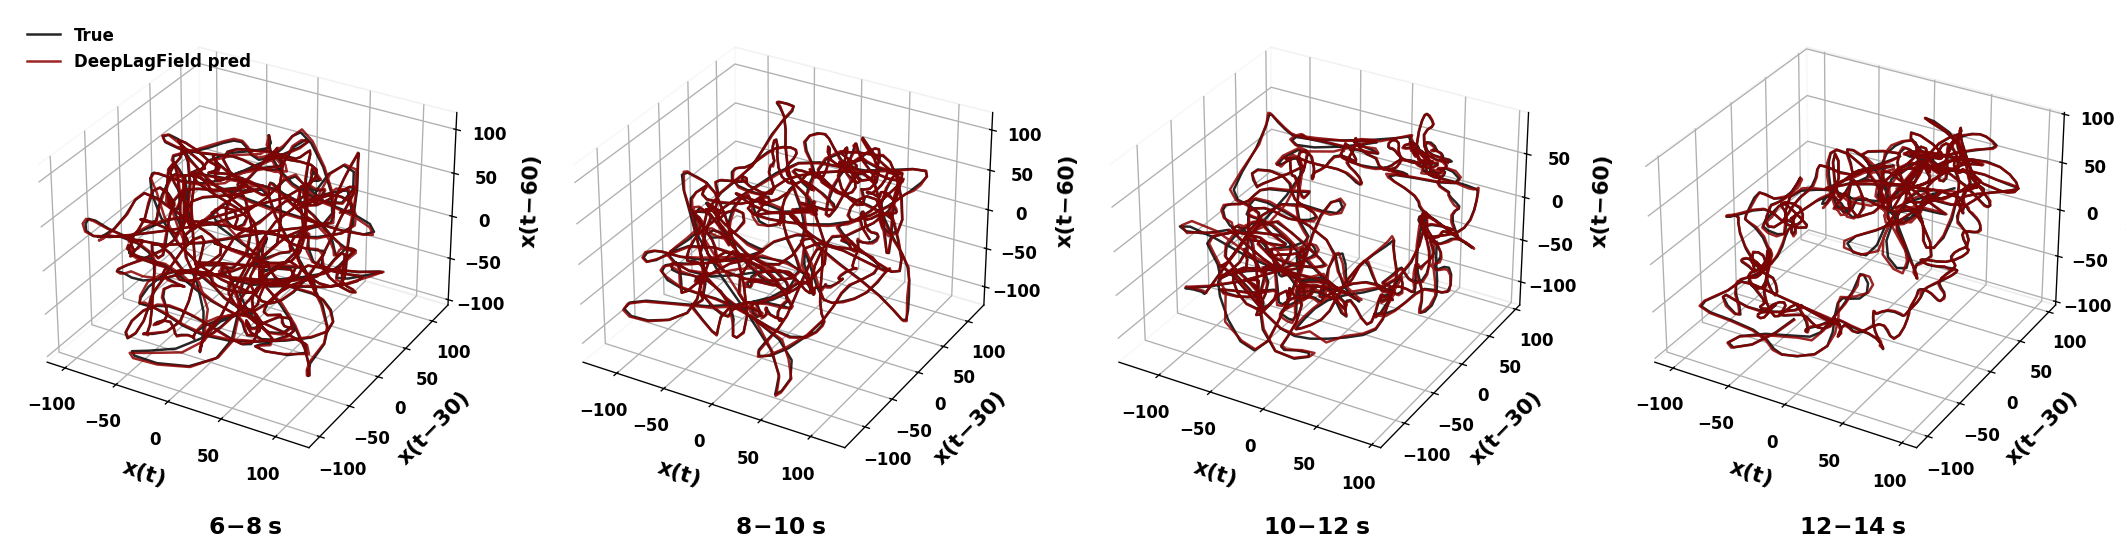

/tmp/ipykernel_13524/343154526.py:51: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(pad=2.5, w_pad=1.5)


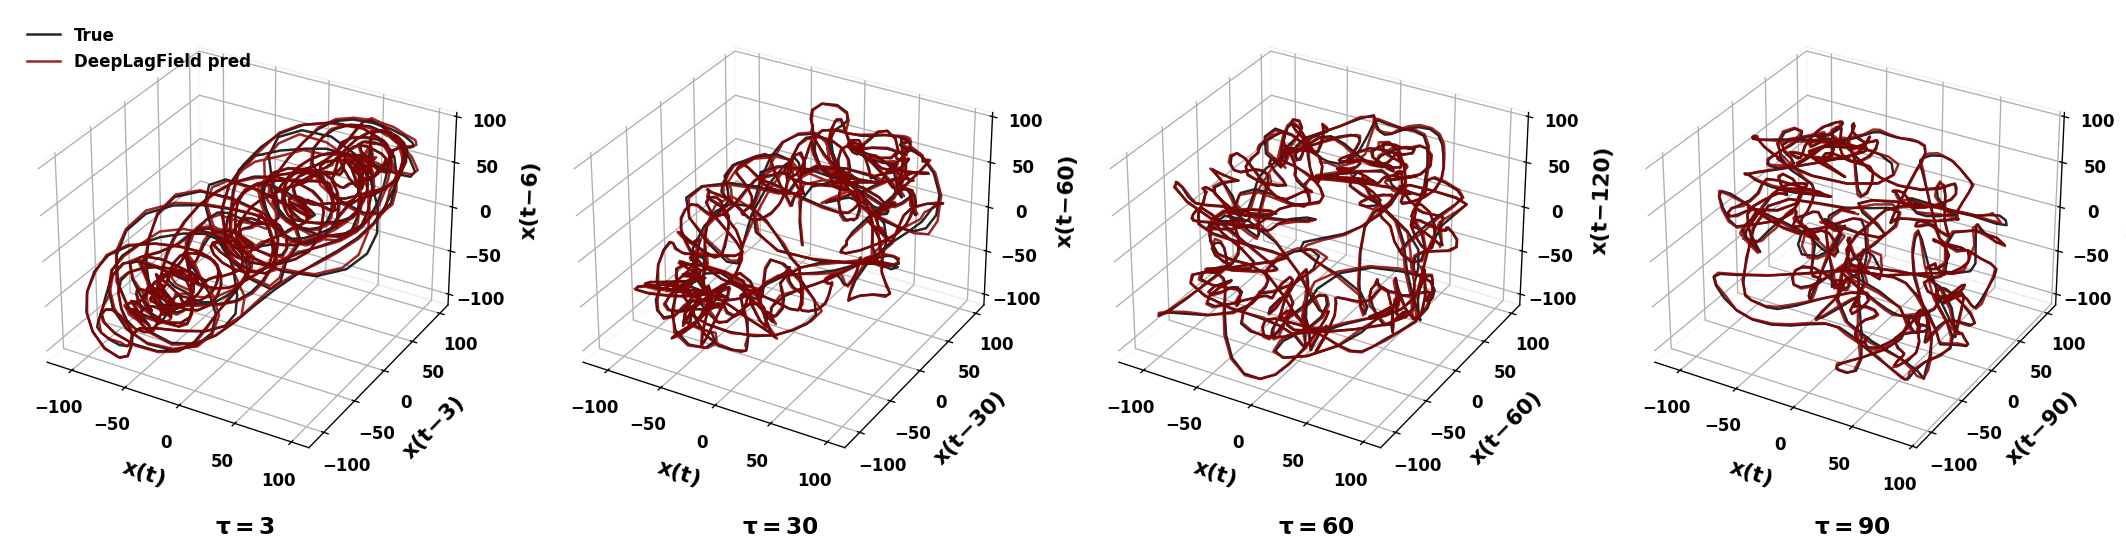

In [23]:
filled_deeplag = np.nan_to_num(xs_deeplag_full, nan=np.nanmean(xs))

plot_state_space_windows_comparison(
    xs,
    filled_deeplag,
    Fs,
    tau,
    pred_label="DeepLagField pred",
)

plot_state_space_tau_sweep(
    xs,
    filled_deeplag,
    Fs,
    t_start=18,
    t_end=20,
    pred_label="DeepLagField pred",
)


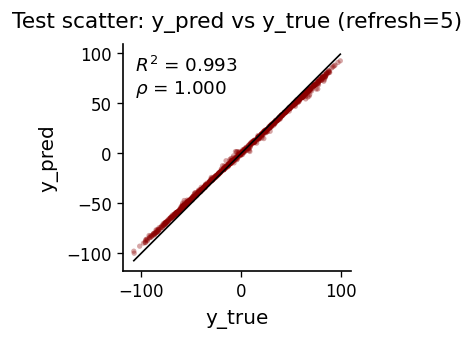

In [24]:
plot_scatter(
    deeplag_test_true[mask],
    deeplag_test_pred[mask],
    REFRESH_EVERY,
)